# Imports

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
left_image = cv2.imread('left.png', cv2.IMREAD_GRAYSCALE)
right_image = cv2.imread('right.png', cv2.IMREAD_GRAYSCALE)

In [3]:
def compute_disparity_block_matching(I_l, I_r, window_size, method='SAD', max_disparity=64):
    """
    Compute disparity map using block matching
    
    Args:
        I_l: Left image (grayscale)
        I_r: Right image (grayscale) 
        window_size: Size of the matching window (odd number)
        method: 'SAD' or 'SSD'
        max_disparity: Maximum disparity to search for
    
    Returns:
        disparity_map: Disparity values for each pixel
    """
    height, width = I_l.shape
    k = window_size // 2  # Half window size
    disparity_map = np.zeros_like(I_l, dtype=np.float32)
    
    # Convert to float for calculations
    I_l = I_l.astype(np.float32)
    I_r = I_r.astype(np.float32)
    
    print(f"Computing disparity with {method}, window_size={window_size}...")
    
    # Only compute where full window fits + account for max_disparity
    for y in range(k, height - k):
        if y % 50 == 0:  # Progress indicator
            print(f"Processing row {y}/{height}")
            
        for x in range(max_disparity + k, width - k):
            best_cost = float('inf')
            best_d = 0
            
            # Search through all possible disparities
            for d in range(max_disparity):
                if x - d - k < 0:  # Ensure window doesn't go out of bounds on left
                    continue
                    
                cost = 0
                
                # Compute cost over the window
                for dx in range(-k, k + 1):
                    for dy in range(-k, k + 1):
                        val_l = I_l[y + dy, x + dx]
                        val_r = I_r[y + dy, x + dx - d]  # Search in right image
                        
                        if method == 'SAD':
                            cost += abs(val_l - val_r)
                        else:  # SSD
                            diff = val_l - val_r
                            cost += diff * diff
                
                # Update best match
                if cost < best_cost:
                    best_cost = cost
                    best_d = d
            
            disparity_map[y, x] = best_d
    
    return disparity_map

In [4]:
def normalize_disparity(disparity_map):
    """Normalize disparity map for visualization"""
    valid_pixels = disparity_map[disparity_map > 0]
    if len(valid_pixels) > 0:
        min_val = np.min(valid_pixels)
        max_val = np.max(valid_pixels)
        if max_val > min_val:
            normalized = (disparity_map - min_val) / (max_val - min_val) * 255
            return normalized.astype(np.uint8)
    return np.zeros_like(disparity_map, dtype=np.uint8)

In [5]:
def plot_results_simple(I_l, I_r, disparity_maps, window_sizes, methods):
    fig, axes = plt.subplots(4, 2, figsize=(12, 15))
    
    # Plot original images in first row, spanning both columns
    axes[0, 0].imshow(I_l, cmap='gray')
    axes[0, 0].set_title('Left Image', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(I_r, cmap='gray')
    axes[0, 1].set_title('Right Image', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    # Plot disparity maps in rows 2 and 3
    row_idx = 1
    for window_size in window_sizes:
        axes[row_idx, 0].imshow(disparity_maps[window_size]['SAD'], cmap='jet')
        axes[row_idx, 0].set_title(f'W={window_size} SAD', fontsize=11)
        axes[row_idx, 0].axis('off')
        
        axes[row_idx, 1].imshow(disparity_maps[window_size]['SSD'], cmap='jet')
        axes[row_idx, 1].set_title(f'W={window_size} SSD', fontsize=11)
        axes[row_idx, 1].axis('off')
        
        row_idx += 1
    
    plt.tight_layout()
    plt.show()

In [6]:
# Parameters
window_sizes = [1, 5, 9]
methods = ['SAD', 'SSD']
max_disparity = 64

# Store all results
disparity_maps = {ws: {} for ws in window_sizes}

# Compute all disparity maps
for window_size in window_sizes:
    for method in methods:
        disparity_map = compute_disparity_block_matching(
            left_image, right_image, window_size, method, max_disparity
        )
        # Normalize for visualization
        disparity_normalized = normalize_disparity(disparity_map)
        disparity_maps[window_size][method] = disparity_normalized
        
        # Save individual results
        filename = f'disparity_{method}_w{window_size}.png'
        cv2.imwrite(filename, disparity_normalized)
        print(f"Saved {filename}")

Computing disparity with SAD, window_size=1...
Processing row 0/288
Processing row 50/288
Processing row 100/288
Processing row 150/288
Processing row 200/288
Processing row 250/288
Saved disparity_SAD_w1.png
Computing disparity with SSD, window_size=1...
Processing row 0/288
Processing row 50/288
Processing row 100/288
Processing row 150/288
Processing row 200/288
Processing row 250/288
Saved disparity_SSD_w1.png
Computing disparity with SAD, window_size=5...
Processing row 50/288
Processing row 100/288
Processing row 150/288
Processing row 200/288
Processing row 250/288
Saved disparity_SAD_w5.png
Computing disparity with SSD, window_size=5...
Processing row 50/288
Processing row 100/288
Processing row 150/288
Processing row 200/288
Processing row 250/288
Saved disparity_SSD_w5.png
Computing disparity with SAD, window_size=9...
Processing row 50/288
Processing row 100/288
Processing row 150/288
Processing row 200/288
Processing row 250/288
Saved disparity_SAD_w9.png
Computing disparit

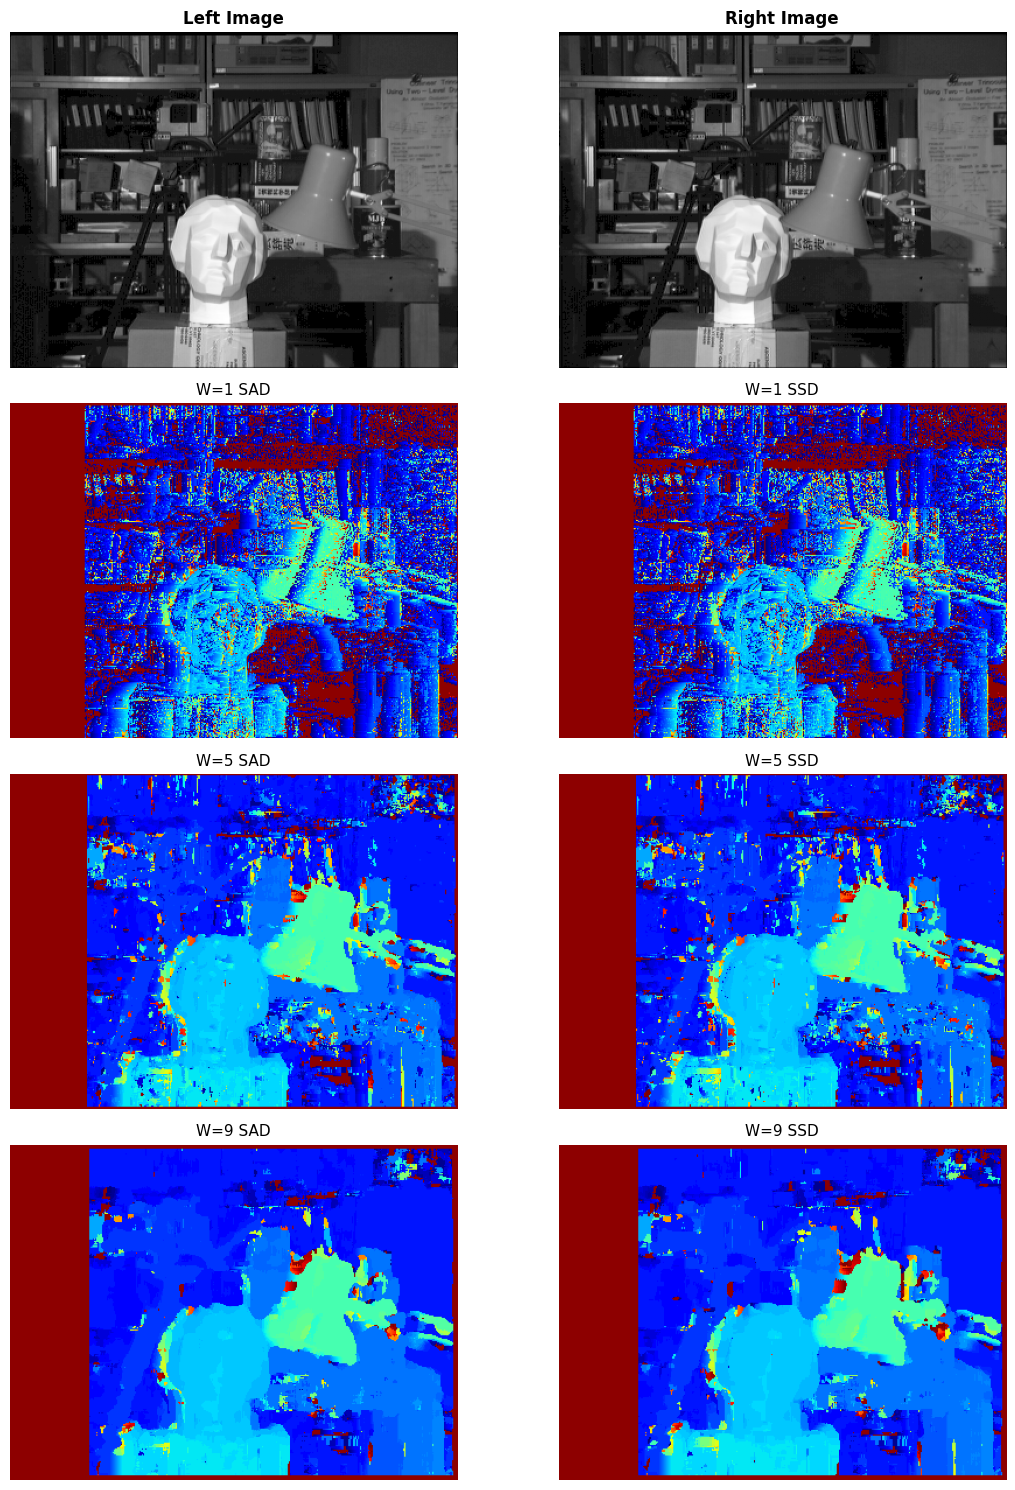


=== Disparity Statistics ===
SAD w1: min=4.0, max=255.0, mean=122.3
SSD w1: min=4.0, max=255.0, mean=122.3
SAD w5: min=4.0, max=255.0, mean=100.3
SSD w5: min=4.0, max=255.0, mean=100.9
SAD w9: min=4.0, max=255.0, mean=100.5
SSD w9: min=4.0, max=255.0, mean=101.5


In [7]:
# Plot all results
plot_results_simple(left_image, right_image, disparity_maps, window_sizes, methods)

# Print statistics
print("\n=== Disparity Statistics ===")
for window_size in window_sizes:
    for method in methods:
        disparity = disparity_maps[window_size][method]
        valid_pixels = disparity[disparity > 0]
        if len(valid_pixels) > 0:
            print(f"{method} w{window_size}: min={np.min(valid_pixels):.1f}, "
                  f"max={np.max(valid_pixels):.1f}, "
                  f"mean={np.mean(valid_pixels):.1f}")

In [ ]:
def compute_disparity_dp(I_l, I_r, sigma=2.0, c0=1.0):
    # Ensure float for cost computations
    I_l = I_l.astype(np.float32)
    I_r = I_r.astype(np.float32)

    height, width = I_l.shape

    # Disparity maps for left and right images
    disp_left = np.zeros((height, width), dtype=np.float32)
    disp_right = np.zeros((height, width), dtype=np.float32)

    for y in range(height):
        # One scanline from each image
        Il_row = I_l[y, :]
        Ir_row = I_r[y, :]
        N = width

        # Cost of matching pixel Il(i) with Ir(j)
        # dij = (Il(i) - Ir(j))^2 / sigma^2
        diff = Il_row[:, None] - Ir_row[None, :]
        d = (diff * diff) / (sigma * sigma)

        # Dynamic programming matrix D, with an extra row and column for index 0
        # D[i, j] is the minimal cost of aligning Il[0..i-1] with Ir[0..j-1]
        D = np.zeros((N + 1, N + 1), dtype=np.float32)

        # Initialization: skipping pixels at the beginning
        for i in range(1, N + 1):
            D[i, 0] = i * c0
        for j in range(1, N + 1):
            D[0, j] = j * c0

        # Fill DP table
        for i in range(1, N + 1):
            for j in range(1, N + 1):
                cost_match = D[i - 1, j - 1] + d[i - 1, j - 1]
                cost_skip_left = D[i - 1, j] + c0    # skip Il(i-1)
                cost_skip_right = D[i, j - 1] + c0   # skip Ir(j-1)
                D[i, j] = min(cost_match, cost_skip_left, cost_skip_right)

        # Backtracking from (N, N) to (0, 0)
        i, j = N, N
        eps = 1e-6  # tolerance for float comparisons

        while i > 0 or j > 0:
            # Match Il(i-1) with Ir(j-1)
            if i > 0 and j > 0 and abs(D[i, j] - (D[i - 1, j - 1] + d[i - 1, j - 1])) <= eps:
                disparity = abs((i - 1) - (j - 1))
                disp_left[y, i - 1] = disparity
                disp_right[y, j - 1] = disparity
                i -= 1
                j -= 1

            # Skip Il(i-1) (occluded in left image)
            elif i > 0 and abs(D[i, j] - (D[i - 1, j] + c0)) <= eps:
                disp_left[y, i - 1] = 0.0
                i -= 1

            # Skip Ir(j-1) (occluded in right image)
            else:
                disp_right[y, j - 1] = 0.0
                j -= 1

    return disp_left, disp_right


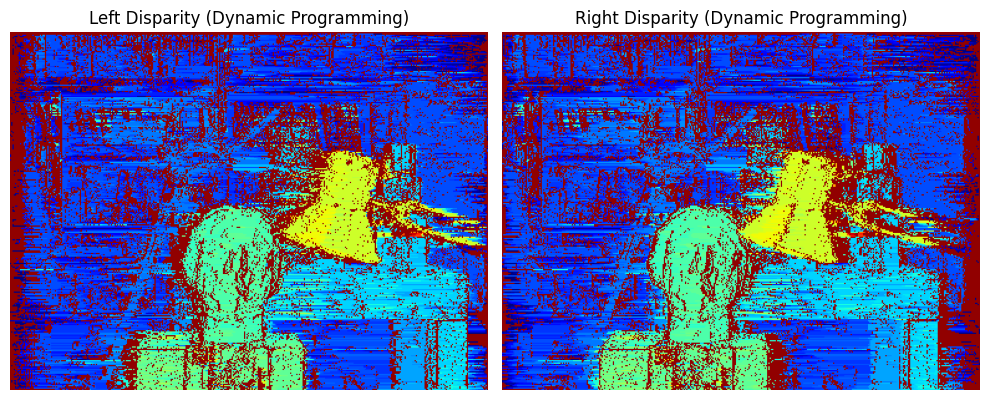

Saved disparity_dp_left.png and disparity_dp_right.png


In [ ]:
# Dynamic programming parameters
sigma = 2.0
c0 = 1.0

# Compute disparity maps using dynamic programming
disp_left_dp, disp_right_dp = compute_disparity_dp(left_image, right_image, sigma=sigma, c0=c0)

# Normalize for visualization using your existing helper
disp_left_dp_norm = normalize_disparity(disp_left_dp)
disp_right_dp_norm = normalize_disparity(disp_right_dp)

# Visualize the DP disparity maps
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(disp_left_dp_norm, cmap='jet')
plt.title('Left Disparity (Dynamic Programming)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(disp_right_dp_norm, cmap='jet')
plt.title('Right Disparity (Dynamic Programming)')
plt.axis('off')

plt.tight_layout()
plt.show()

# Optionally save the images
cv2.imwrite('disparity_dp_left.png', disp_left_dp_norm)
cv2.imwrite('disparity_dp_right.png', disp_right_dp_norm)
print("Saved disparity_dp_left.png and disparity_dp_right.png")


In [ ]:
def plot_dp_alignment_for_row(I_l, I_r, row_index, sigma=2.0, c0=1.0):
    I_l = I_l.astype(np.float32)
    I_r = I_r.astype(np.float32)

    Il_row = I_l[row_index, :]
    Ir_row = I_r[row_index, :]
    N = Il_row.shape[0]

    # dij = (Il(i) - Ir(j))^2 / sigma^2
    diff = Il_row[:, None] - Ir_row[None, :]
    d = (diff * diff) / (sigma * sigma)

    # DP table D of size (N+1)x(N+1)
    D = np.zeros((N + 1, N + 1), dtype=np.float32)

    # Initialise borders (skipping pixels)
    for i in range(1, N + 1):
        D[i, 0] = i * c0
    for j in range(1, N + 1):
        D[0, j] = j * c0

    # Fill DP
    for i in range(1, N + 1):
        for j in range(1, N + 1):
            cost_match = D[i - 1, j - 1] + d[i - 1, j - 1]
            cost_skip_left = D[i - 1, j] + c0    # skip Il(i-1)
            cost_skip_right = D[i, j - 1] + c0   # skip Ir(j-1)
            D[i, j] = min(cost_match, cost_skip_left, cost_skip_right)

    # Backtrack from (N, N) to (0, 0) and record the path
    i, j = N, N
    path_i = [i]
    path_j = [j]
    eps = 1e-6

    while i > 0 or j > 0:
        # Prefer match if it fits
        if i > 0 and j > 0 and abs(D[i, j] - (D[i - 1, j - 1] + d[i - 1, j - 1])) <= eps:
            i, j = i - 1, j - 1      # diagonal move: match
        elif i > 0 and abs(D[i, j] - (D[i - 1, j] + c0)) <= eps:
            i, j = i - 1, j          # vertical move: skip Il
        else:
            j = j - 1                # horizontal move: skip Ir

        path_i.append(i)
        path_j.append(j)

    # Reverse so the plot starts near (0,0)/(1,1)
    path_i = path_i[::-1]
    path_j = path_j[::-1]

    # Plot Il (vertical, y-axis) vs Ir (horizontal, x-axis)
    plt.figure(figsize=(6, 6))
    plt.plot(path_j, path_i, linewidth=1)
    # Optional: reference diagonal (perfect alignment)
    plt.plot([0, N], [0, N], linestyle='--', alpha=0.5)

    plt.xlim(0, N)
    plt.ylim(0, N)
    plt.xlabel("Ir index (j)")
    plt.ylabel("Il index (i)")
    plt.title(f"DP Alignment Path for Row {row_index}")
    plt.gca().set_aspect('equal', 'box')
    plt.grid(True, alpha=0.3)
    plt.show()


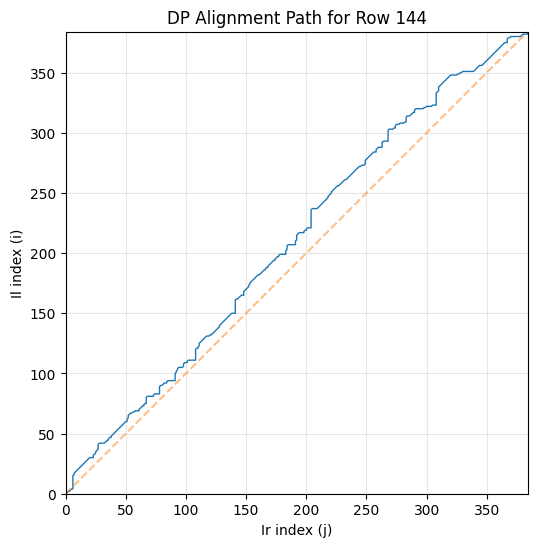

In [ ]:

row_to_visualise = left_image.shape[0] // 2

plot_dp_alignment_for_row(left_image, right_image,row_index=row_to_visualise,sigma=2.0,c0=1.0)
